In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your local raw datasets
df_fraud = pd.read_csv('../data/raw/Fraud_Data.csv')
df_ip = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

# Ensure datetime types
df_fraud['signup_time'] = pd.to_datetime(df_fraud['signup_time'])
df_fraud['purchase_time'] = pd.to_datetime(df_fraud['purchase_time'])

print(f"Fraud Dataset: {df_fraud.shape}")
print(f"IP Range Dataset: {df_ip.shape}")

Fraud Dataset: (151112, 11)
IP Range Dataset: (138846, 3)


Legitimate Transactions (Class 0): 90.64%
Fraudulent Transactions (Class 1): 9.36%


C:\Users\Helen\AppData\Local\Temp\ipykernel_27812\1034272151.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df_fraud, palette='viridis')


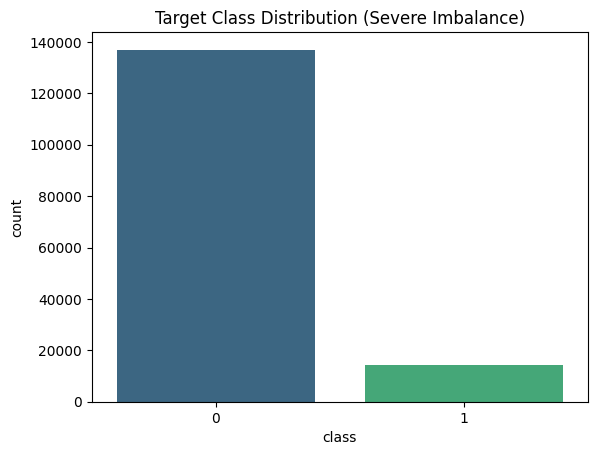

In [4]:
imbalance = df_fraud['class'].value_counts(normalize=True) * 100
print(f"Legitimate Transactions (Class 0): {imbalance[0]:.2f}%")
print(f"Fraudulent Transactions (Class 1): {imbalance[1]:.2f}%")

# Quick visual of target distribution
sns.countplot(x='class', data=df_fraud, palette='viridis')
plt.title('Target Class Distribution (Severe Imbalance)')
plt.show()

In [5]:
# 1. Sort both dataframes by the IP values (strict requirement for merge_asof)
df_fraud = df_fraud.sort_values('ip_address')
df_ip = df_ip.sort_values('lower_bound_ip_address')

# 2. Perform the optimized range-based lookup merge
# merge_asof matches on the nearest lower bound
df_merged = pd.merge_asof(
    df_fraud, 
    df_ip, 
    left_on='ip_address', 
    right_on='lower_bound_ip_address', 
    direction='backward'
)

# 3. Post-merge boundary check: Verify that the IP is truly <= the upper bound
# If it is greater than the upper bound, it doesn't belong to that country block
invalid_mask = df_merged['ip_address'] > df_merged['upper_bound_ip_address']
df_merged.loc[invalid_mask, 'country'] = 'Unknown'

# Fill any remaining unmapped NaN IPs with Unknown
df_merged['country'] = df_merged['country'].fillna('Unknown')

print(f"Merged Dataset Shape: {df_merged.shape}")

Merged Dataset Shape: (151112, 14)


In [7]:
# Compute total transactions and fraud rates per country
country_stats = df_merged.groupby('country').agg(
    total_transactions=('class', 'count'),
    fraud_cases=('class', 'sum'),
    fraud_rate=('class', 'mean')
).reset_index()

# Filter for countries with significant transaction volume (e.g., > 100 transactions)
top_fraud_countries = country_stats[country_stats['total_transactions'] > 100].sort_values(by='fraud_rate', ascending=False)

print("Top 10 Highest Risk Countries by Fraud Rate:")
print(top_fraud_countries.head(10))

Top 10 Highest Risk Countries by Fraud Rate:
                  country  total_transactions  fraud_cases  fraud_rate
51                Ecuador                 106           28    0.264151
164               Tunisia                 118           31    0.262712
131                  Peru                 119           31    0.260504
80                Ireland                 240           55    0.229167
120           New Zealand                 278           62    0.223022
144          Saudi Arabia                 264           50    0.189394
47                Denmark                 490           78    0.159184
35                  Chile                 417           64    0.153477
67                 Greece                 231           33    0.142857
169  United Arab Emirates                 114           16    0.140351


In [5]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x='fraud_rate', 
    y='country', 
    data=top_fraud_countries.head(10), 
    palette='Reds_r'
)
plt.title('Top 10 Highest Fraud Rates by Country (Minimum 100 Transactions)')
plt.xlabel('Fraud Probability (Mean)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [4]:
df_merged.to_csv('../data/processed/ecommerce_cleaned_geo.csv', index=False)

NameError: name 'df_merged' is not defined